# Evaluación de rentabilidad

Este notebook evalúa el resultado económico del **backtest de apuestas** generado por el modelo. La pregunta central no es solo cuánto dinero terminó ganando la estrategia, sino cuánto obtuvo por cada unidad apostada, qué riesgo asumió y si el resultado se mantiene al separar mercados y niveles de valor esperado.

- **ROI:** beneficio neto dividido entre el capital total apostado. Mide la eficiencia de la estrategia, no el crecimiento de la cuenta.
- **Balance:** capital inicial más el P/L acumulado. Se observa al cierre de cada fecha con actividad.
- **Drawdown:** caída del balance diario desde su máximo anterior. Resume el riesgo experimentado durante el periodo.
- **EV:** ventaja estimada por el modelo antes de conocer el resultado.

El análisis describe un backtest histórico. No demuestra que el mismo rendimiento vaya a repetirse fuera de muestra o en producción.

In [1]:
from pathlib import Path
import warnings

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

warnings.filterwarnings("ignore", category=UserWarning)

BLUE = "#2563EB"
BLUE_LIGHT = "#BFDBFE"
GOLD = "#D89B19"
GOLD_LIGHT = "#FDE7A9"
INK = "#1F2937"
MUTED = "#6B7280"
GRID = "#E5E7EB"
PAPER = "#FCFCFA"
GREY = "#9CA3AF"
GREY_LIGHT = "#EEF0F3"

plt.rcParams.update({
    "figure.facecolor": PAPER,
    "axes.facecolor": PAPER,
    "axes.edgecolor": GRID,
    "axes.labelcolor": INK,
    "text.color": INK,
    "xtick.color": MUTED,
    "ytick.color": MUTED,
    "font.size": 11.5,
    "axes.titleweight": "bold",
})


def clean_axes(ax, grid_axis="y", keep_left=True, keep_bottom=True):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(keep_left)
    ax.spines["bottom"].set_visible(keep_bottom)
    ax.grid(axis=grid_axis, color=GRID, linewidth=0.8, alpha=0.8)
    ax.set_axisbelow(True)


def finish_chart(fig, subtitle, y=0.90):
    fig.text(0.06, y, subtitle, fontsize=10.3, color=MUTED, ha="left")


data_candidates = [Path("02_data"), Path("../02_data")]
DATA_DIR = next((path for path in data_candidates if path.exists()), None)
if DATA_DIR is None:
    raise FileNotFoundError("No se encontró la carpeta 02_data")

SOURCE_PATH = DATA_DIR / "betting_results.xlsx"
raw_bets = pd.read_excel(SOURCE_PATH)

required_columns = [
    "Match", "Date", "Market", "Market Group", "Odds", "Market Odds", "EV",
    "Result", "Bet Amount", "PL Amount", "Balance",
]
missing_columns = set(required_columns) - set(raw_bets.columns)
assert not missing_columns, f"Faltan columnas requeridas: {sorted(missing_columns)}"

bets = raw_bets.copy()
bets["Date"] = pd.to_datetime(bets["Date"], errors="raise")
numeric_columns = ["Odds", "Market Odds", "EV", "Result", "Bet Amount", "PL Amount", "Balance"]
for column in numeric_columns:
    bets[column] = pd.to_numeric(bets[column], errors="raise")

bets = bets.sort_values("Date", kind="stable").reset_index(drop=True)
assert not bets[required_columns].isna().any().any()
assert not bets.duplicated().any()
assert (bets["Bet Amount"] >= 0).all()
assert (bets["Market Odds"] > 0).all()

source_label = "02_data/betting_results.xlsx"
coverage = pd.DataFrame({
    "Indicador": ["Archivo fuente", "Apuestas", "Partidos", "Mercados", "Periodo", "Valores faltantes"],
    "Valor": [
        source_label,
        f"{len(bets):,}",
        f"{bets[['Date', 'Match']].drop_duplicates().shape[0]:,}",
        f"{bets['Market Group'].nunique():,}",
        f"{bets['Date'].min():%d/%m/%Y} – {bets['Date'].max():%d/%m/%Y}",
        f"{int(bets[required_columns].isna().sum().sum()):,}",
    ],
})

display(coverage.set_index("Indicador"))

,Valor
Indicador,
Archivo fuente,02_data/betting_results.xlsx
Apuestas,"5,101"
Partidos,481
Mercados,4
Periodo,03/01/2025 – 27/04/2025
Valores faltantes,0


## Datos y preparación

In [2]:
total_bets = len(bets)
total_wagered = bets["Bet Amount"].sum()
total_profit = bets["PL Amount"].sum()
roi = total_profit / total_wagered
win_rate = (bets["PL Amount"] > 0).mean()
push_rate = (bets["PL Amount"] == 0).mean()
final_balance = bets["Balance"].iloc[-1]
initial_bankroll = final_balance - total_profit
bankroll_return = final_balance / initial_bankroll - 1

daily = (
    bets.groupby("Date", as_index=False)
    .agg(Apuestas=("PL Amount", "size"), Apostado=("Bet Amount", "sum"), Beneficio=("PL Amount", "sum"))
)
daily["Balance"] = initial_bankroll + daily["Beneficio"].cumsum()
daily_peak = np.maximum.accumulate(np.r_[initial_bankroll, daily["Balance"].to_numpy()])[1:]
daily["Drawdown"] = daily["Balance"] / daily_peak - 1
max_drawdown = daily["Drawdown"].min()
max_drawdown_date = daily.loc[daily["Drawdown"].idxmin(), "Date"]

summary = pd.DataFrame({
    "Indicador": [
        "Apuestas", "Capital apostado", "Beneficio neto", "ROI",
        "Balance final", "Retorno del bankroll", "Tasa de acierto", "Drawdown máximo",
    ],
    "Resultado": [
        f"{total_bets:,}",
        f"${total_wagered:,.0f}",
        f"${total_profit:,.0f}",
        f"{roi:.2%}",
        f"${final_balance:,.0f}",
        f"{bankroll_return:.1%}",
        f"{win_rate:.1%}",
        f"{max_drawdown:.1%}",
    ],
})

display(summary.set_index("Indicador"))

,Resultado
Indicador,
Apuestas,"5,101"
Capital apostado,"$1,477,775"
Beneficio neto,"$129,420"
ROI,8.76%
Balance final,"$139,420"
Retorno del bankroll,1294.2%
Tasa de acierto,31.9%
Drawdown máximo,-67.3%


## Evolución del balance y riesgo

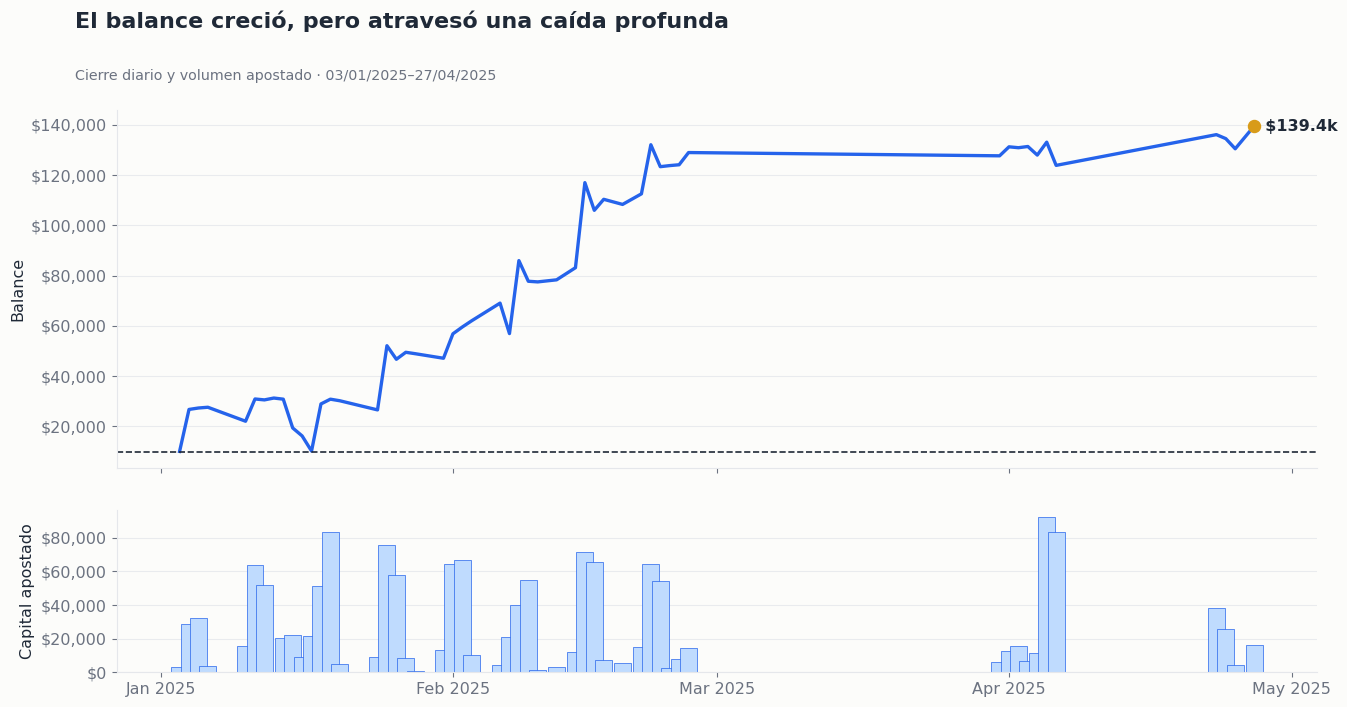

In [3]:
daily = (
    bets.groupby("Date", as_index=False)
    .agg(Apuestas=("PL Amount", "size"), Apostado=("Bet Amount", "sum"), Beneficio=("PL Amount", "sum"))
)
daily["Balance"] = initial_bankroll + daily["Beneficio"].cumsum()

fig, (ax_balance, ax_volume) = plt.subplots(
    2, 1, figsize=(13.8, 7.4), sharex=True,
    gridspec_kw={"height_ratios": [2.2, 1], "hspace": 0.16},
)

ax_balance.plot(daily["Date"], daily["Balance"], color=BLUE, linewidth=2.4)
ax_balance.axhline(initial_bankroll, color=INK, linewidth=1.2, linestyle="--")
ax_balance.scatter(daily["Date"].iloc[-1], daily["Balance"].iloc[-1], color=GOLD, s=75, zorder=3)
ax_balance.text(
    daily["Date"].iloc[-1], daily["Balance"].iloc[-1],
    f"  ${final_balance/1000:.1f}k", va="center", color=INK, fontweight="bold",
)
ax_balance.set_ylabel("Balance")
ax_balance.yaxis.set_major_formatter(ticker.StrMethodFormatter("${x:,.0f}"))
clean_axes(ax_balance, grid_axis="y")

ax_volume.bar(daily["Date"], daily["Apostado"], width=1.8, color=BLUE_LIGHT, edgecolor=BLUE, linewidth=0.5)
ax_volume.set_ylabel("Capital apostado")
ax_volume.yaxis.set_major_formatter(ticker.StrMethodFormatter("${x:,.0f}"))
ax_volume.xaxis.set_major_locator(mdates.MonthLocator())
ax_volume.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
clean_axes(ax_volume, grid_axis="y")

fig.suptitle(
    "El balance creció, pero atravesó una caída profunda",
    x=0.06, y=0.995, ha="left", fontsize=16, fontweight="bold",
)
finish_chart(
    fig,
    f"Cierre diario y volumen apostado · {daily['Date'].min():%d/%m/%Y}–{daily['Date'].max():%d/%m/%Y}",
)
fig.subplots_adjust(left=0.09, right=0.96, bottom=0.10, top=0.86, hspace=0.18)
plt.show()

## Por Mercados

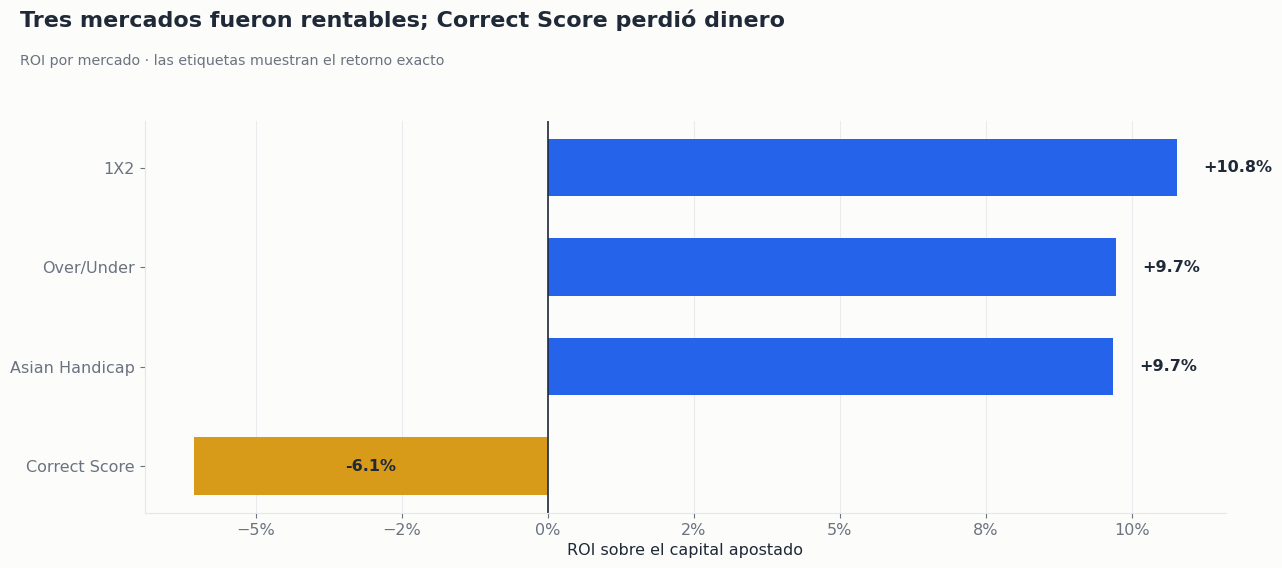

,Apuestas,Apostado,Beneficio,ROI,Acierto
Mercado,,,,,
Correct Score,1477,"$100,859","$-6,110",-6.1%,6.3%
Asian Handicap,1798,"$706,036","$68,291",9.7%,40.7%
Over/Under,1178,"$487,316","$47,453",9.7%,52.3%
1X2,648,"$183,564","$19,786",10.8%,28.4%


In [4]:
market_summary = (
    bets.groupby("Market Group")
    .agg(
        Apuestas=("PL Amount", "size"),
        Ganadas=("PL Amount", lambda values: (values > 0).sum()),
        Perdidas=("PL Amount", lambda values: (values < 0).sum()),
        Pushes=("PL Amount", lambda values: (values == 0).sum()),
        Apostado=("Bet Amount", "sum"),
        Beneficio=("PL Amount", "sum"),
    )
)
market_summary["ROI"] = market_summary["Beneficio"] / market_summary["Apostado"]
market_summary["Acierto"] = market_summary["Ganadas"] / market_summary["Apuestas"]
market_summary = market_summary.sort_values("ROI")

fig, ax = plt.subplots(figsize=(13.8, 5.8))
colors = [GOLD if value < 0 else BLUE for value in market_summary["ROI"]]
bars = ax.barh(market_summary.index, market_summary["ROI"] * 100, color=colors, height=0.58)
ax.axvline(0, color=INK, linewidth=1.2)

for bar, value in zip(bars, market_summary["ROI"] * 100):
    label_x = value + 0.45 if value >= 0 else value / 2
    ax.text(
        label_x, bar.get_y() + bar.get_height() / 2,
        f"{value:+.1f}%", va="center", ha="left" if value >= 0 else "center",
        fontweight="bold", color=INK,
    )

ax.set_xlabel("ROI sobre el capital apostado")
ax.xaxis.set_major_formatter(ticker.PercentFormatter(xmax=100, decimals=0))
clean_axes(ax, grid_axis="x")
fig.suptitle(
    "Tres mercados fueron rentables; Correct Score perdió dinero",
    x=0.06, y=0.995, ha="left", fontsize=16, fontweight="bold",
)
finish_chart(fig, "ROI por mercado · las etiquetas muestran el retorno exacto")
fig.tight_layout(rect=[0.04, 0.02, 0.98, 0.90])
plt.show()

market_display = market_summary[["Apuestas", "Apostado", "Beneficio", "ROI", "Acierto"]].copy()
market_display["Apostado"] = market_display["Apostado"].map(lambda value: f"${value:,.0f}")
market_display["Beneficio"] = market_display["Beneficio"].map(lambda value: f"${value:,.0f}")
market_display["ROI"] = market_display["ROI"].map(lambda value: f"{value:.1%}")
market_display["Acierto"] = market_display["Acierto"].map(lambda value: f"{value:.1%}")
market_display.index.name = "Mercado"
display(market_display)

## ¿El resultado supera lo esperable sin edge?

La nube representa 10,000 temporadas simuladas usando las cuotas de mercado como probabilidades implícitas, sin ventaja adicional del modelo. El diamante muestra el resultado observado del backtest.

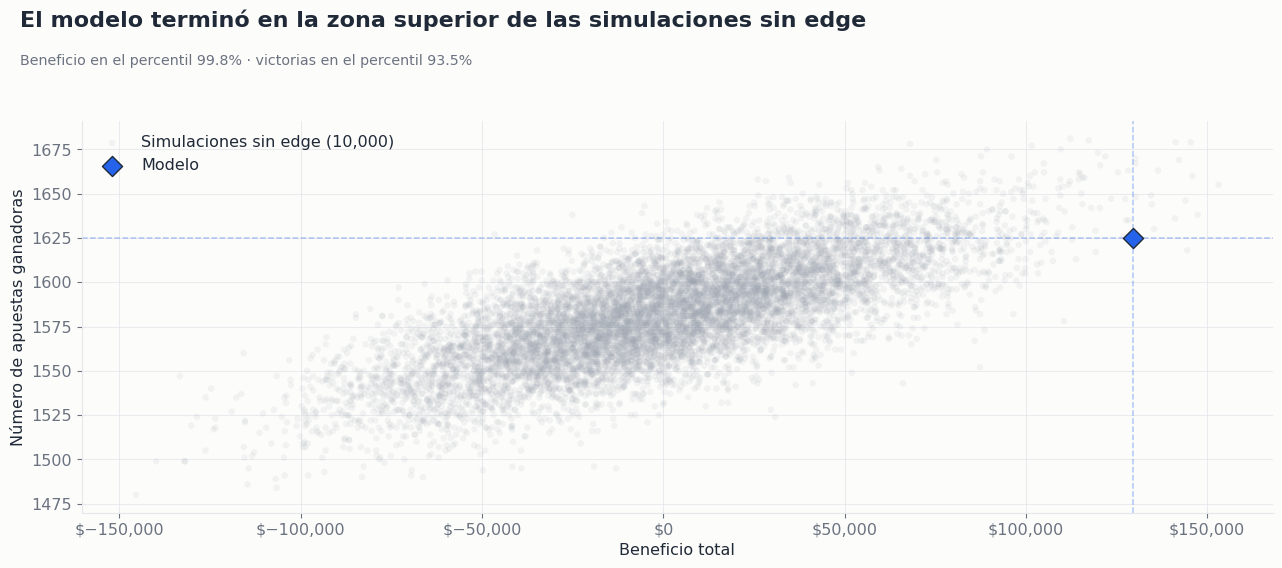

In [5]:
NO_EDGE_SEED = 42
N_NO_EDGE = 10_000
SIMULATION_BATCH = 250

actual_profit = bets["PL Amount"].sum()
actual_wins = (bets["PL Amount"] > 0).sum()
market_odds = bets["Market Odds"].to_numpy()
stakes = bets["Bet Amount"].to_numpy()
implied_win_probability = 1 / market_odds
profit_if_win = (market_odds - 1) * stakes
profit_if_loss = -stakes

rng_no_edge = np.random.default_rng(NO_EDGE_SEED)
simulated_profit = []
simulated_wins = []
for start in range(0, N_NO_EDGE, SIMULATION_BATCH):
    batch_size = min(SIMULATION_BATCH, N_NO_EDGE - start)
    batch_wins = rng_no_edge.random((batch_size, len(bets))) < implied_win_probability
    simulated_profit.append(
        (batch_wins * profit_if_win + (~batch_wins) * profit_if_loss).sum(axis=1)
    )
    simulated_wins.append(batch_wins.sum(axis=1))

simulated_profit = np.concatenate(simulated_profit)
simulated_wins = np.concatenate(simulated_wins)
profit_percentile = (simulated_profit < actual_profit).mean()
win_percentile = (simulated_wins < actual_wins).mean()

fig, ax = plt.subplots(figsize=(13.8, 5.8))
ax.scatter(
    simulated_profit, simulated_wins,
    s=22, color=GREY, alpha=0.11, edgecolors="none",
    label="Simulaciones sin edge (10,000)",
)
ax.scatter(
    actual_profit, actual_wins,
    s=105, marker="D", color=BLUE, edgecolors=INK, linewidth=1.0,
    zorder=4, label="Modelo",
)
ax.axhline(actual_wins, color=BLUE, linestyle="--", linewidth=1.1, alpha=0.35)
ax.axvline(actual_profit, color=BLUE, linestyle="--", linewidth=1.1, alpha=0.35)
ax.set_xlabel("Beneficio total")
ax.set_ylabel("Número de apuestas ganadoras")
ax.xaxis.set_major_formatter(ticker.StrMethodFormatter("${x:,.0f}"))
ax.legend(frameon=False, loc="upper left")
clean_axes(ax, grid_axis="both")
fig.suptitle(
    "El modelo terminó en la zona superior de las simulaciones sin edge",
    x=0.06, y=0.995, ha="left", fontsize=16, fontweight="bold",
)
finish_chart(
    fig,
    f"Beneficio en el percentil {profit_percentile:.1%} · victorias en el percentil {win_percentile:.1%}",
)
fig.tight_layout(rect=[0.04, 0.02, 0.98, 0.90])
plt.show()

## EV frente al beneficio realizado

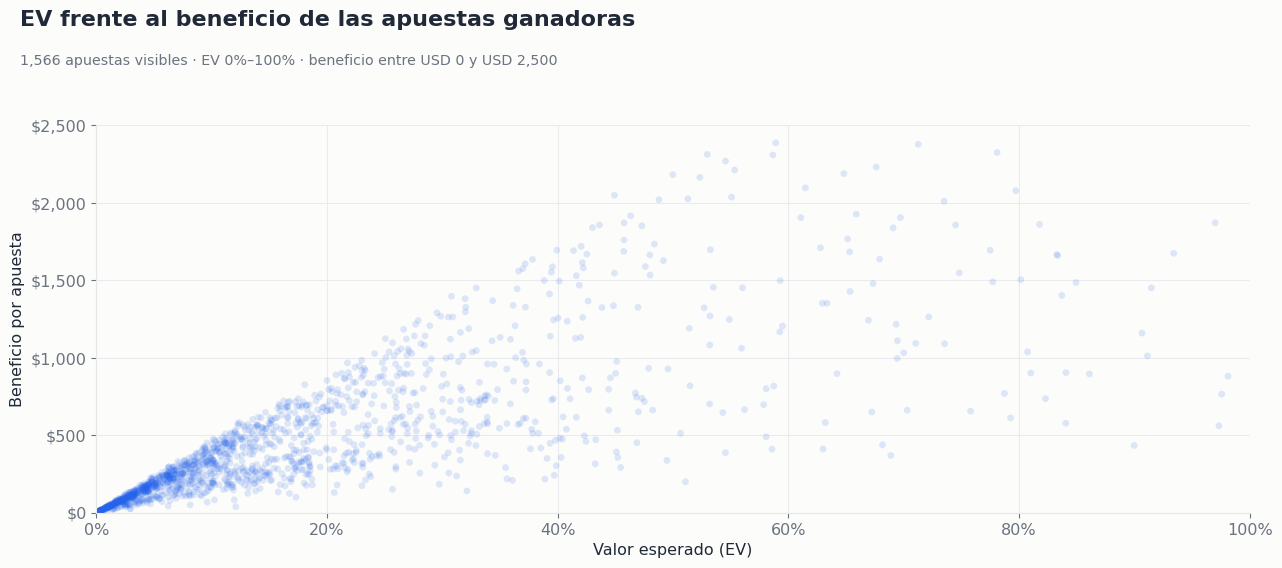

In [6]:
ev_profit_view = bets.loc[
    bets["PL Amount"].gt(0)
    & bets["EV"].between(0, 1)
    & bets["PL Amount"].le(2_500),
    ["EV", "PL Amount"],
].copy()
assert len(ev_profit_view) == 1_566

fig, ax = plt.subplots(figsize=(13.8, 5.8))
ax.scatter(
    ev_profit_view["EV"] * 100, ev_profit_view["PL Amount"],
    s=24, color=BLUE, alpha=0.14, edgecolors="none",
)
ax.set_xlim(0, 100)
ax.set_ylim(0, 2_500)
ax.set_xlabel("Valor esperado (EV)")
ax.set_ylabel("Beneficio por apuesta")
ax.xaxis.set_major_formatter(ticker.PercentFormatter(xmax=100, decimals=0))
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter("${x:,.0f}"))
clean_axes(ax, grid_axis="both")
fig.suptitle(
    "EV frente al beneficio de las apuestas ganadoras",
    x=0.06, y=0.995, ha="left", fontsize=16, fontweight="bold",
)
finish_chart(
    fig,
    f"{len(ev_profit_view):,} apuestas visibles · EV 0%–100% · beneficio entre USD 0 y USD 2,500",
)
fig.tight_layout(rect=[0.04, 0.02, 0.98, 0.90])
plt.show()

## Checks de reproducibilidad

- Fuente congelada: `02_data/betting_results.xlsx`, hoja por defecto.
- Periodo: 03/01/2025–27/04/2025.
- ROI: beneficio neto total dividido entre capital total apostado.
- Balance inicial: balance final menos el beneficio neto total.
- Drawdown: caída del balance al cierre de cada fecha respecto de su máximo acumulado, incluyendo el capital inicial.
- Mercados: cada total se reconcilia contra el portafolio completo.
- Simulación sin edge: 10,000 réplicas con semilla 42; probabilidad de ganar igual a `1 / Market Odds` y pago según la cuota y el importe originales.
- Dispersión EV–beneficio: apuestas ganadoras con EV entre 0% y 100% y `PL Amount` entre $0 y $2,500; 1,566 puntos visibles.
- Las conclusiones se generan desde los valores calculados durante la ejecución.